generate_matern took 0.2384 seconds
generate_student_t took 0.0089 seconds
levy_field took 0.0874 seconds
ising_field took 0.0770 seconds
poisson_field took 0.1117 seconds
generate_cox took 0.0216 seconds


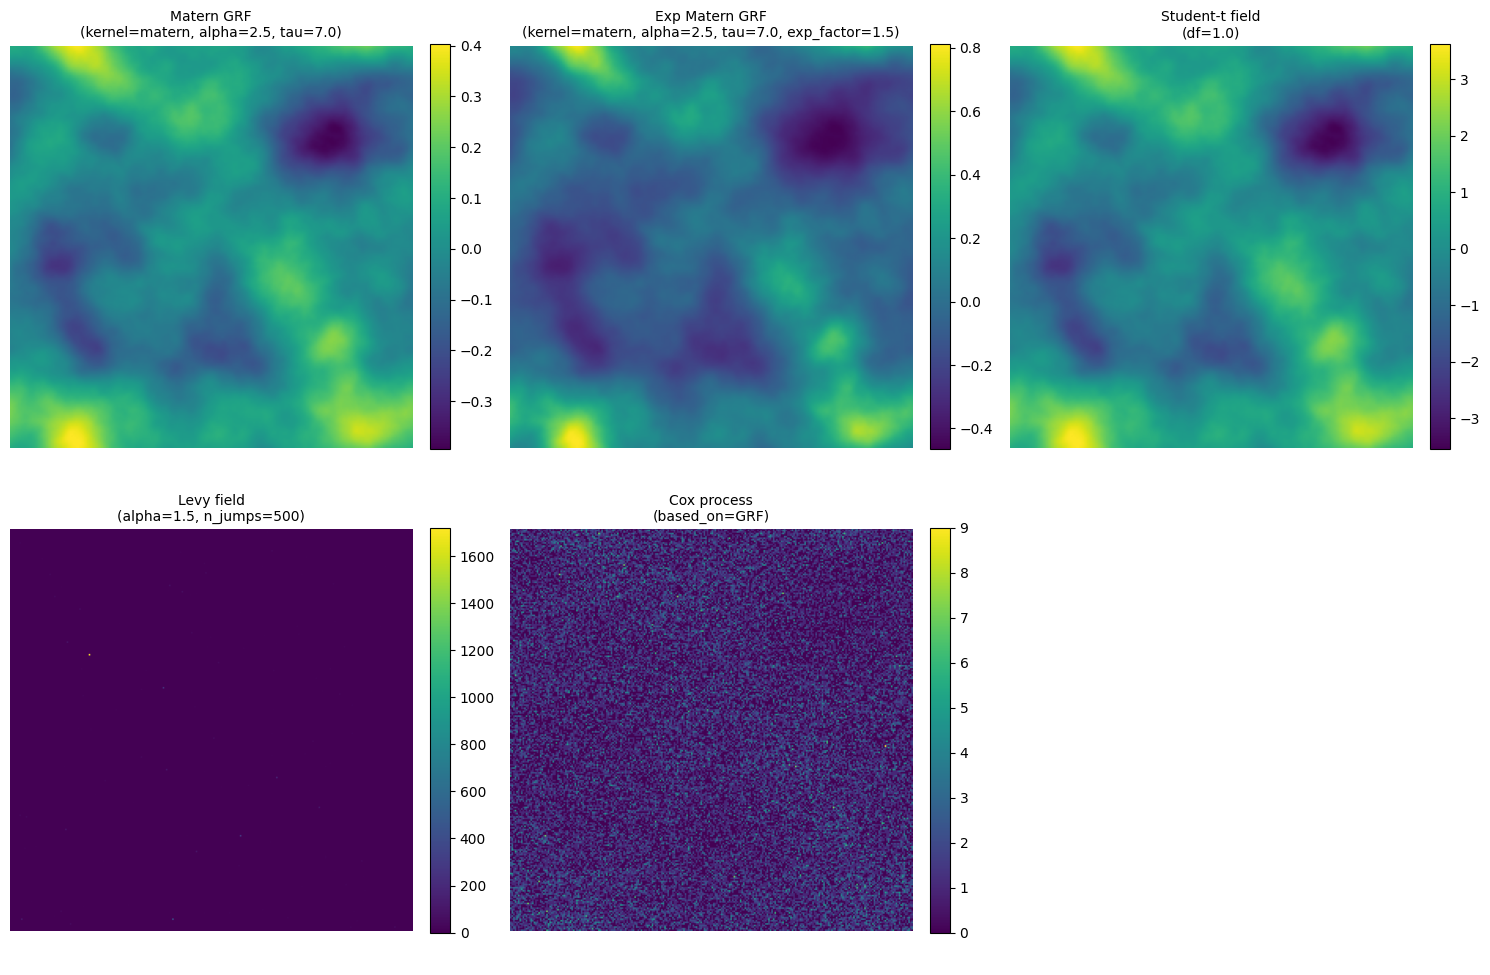

In [ ]:
import torch
import math
import time
import matplotlib.pyplot as plt

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

class PeriodicGRF:
    def __init__(self, dim, size, kernel="matern", device="cpu", **kernel_params):
        """
        dim: 1 or 2
        size: grid size per dim
        kernel: kernel name string
        kernel_params: kernel-specific params
        """
        self.dim = dim
        self.size = size
        self.device = device
        self.kernel = kernel.lower()
        self.params = kernel_params

        freqs_1d = torch.fft.fftfreq(size, d=1.0/size).to(device)

        if dim == 1:
            self.k = freqs_1d
        elif dim == 2:
            kx, ky = torch.meshgrid(freqs_1d, freqs_1d, indexing='ij')
            self.k = torch.sqrt(kx**2 + ky**2)
        else:
            raise NotImplementedError("Only dim=1 or 2 supported.")

        self.sqrt_spec_density = self._compute_sqrt_spectral_density()

    def _compute_sqrt_spectral_density(self):
        k = self.k
        p = self.params
        kernel = self.kernel

        if kernel == "matern":
            # Matern: (4pi^2 k^2 + tau^2)^(-alpha/2)
            alpha = p.get("alpha", 2.5)
            tau = p.get("tau", 7.0)
            sigma = p.get("sigma", tau ** (0.5*(2*alpha - dim)))
            spec = (4 * (math.pi ** 2) * k ** 2 + tau ** 2) ** (-alpha / 2)
            spec[0] = 0.0
            spec = (self.size**self.dim) * math.sqrt(2.0) *  sigma * spec

        elif kernel == "rbf" or kernel == "squared_exponential":
            length_scale = p.get("length_scale", 0.1)
            variance = p.get("variance", 1.0)
            spec = variance * torch.exp(-2 * (math.pi ** 2) * (length_scale ** 2) * k ** 2)
            spec[0] = 0.0

        elif kernel == "exponential":
            length_scale = p.get("length_scale", 0.1)
            variance = p.get("variance", 1.0)
            spec = variance / (1 + (2 * math.pi * length_scale * k) ** 2)
            spec[0] = 0.0

        elif kernel == "rq" or kernel == "rational_quadratic":
            length_scale = p.get("length_scale", 0.1)
            alpha = p.get("alpha", 1.0)
            variance = p.get("variance", 1.0)
            spec = variance * (1 + (k ** 2) / (2 * alpha * length_scale ** 2)) ** (-alpha)
            spec[0] = 0.0

        elif kernel == "periodic":
            # Periodic kernel谱是离散峰，近似实现用多个谱线叠加，简单用正弦谱叠加示例
            # 这里示范用单频率谱峰近似周期性（只能近似）
            length_scale = p.get("length_scale", 0.1)
            variance = p.get("variance", 1.0)
            freq0 = p.get("freq", 1.0)
            # 频率中心峰位置
            spec = torch.zeros_like(k)
            peak_width = 0.05  # 峰宽参数可调
            spec += variance * torch.exp(-((k - freq0) ** 2) / (2 * peak_width ** 2))
            spec += variance * torch.exp(-((k + freq0) ** 2) / (2 * peak_width ** 2))
            spec[0] = 0.0

        elif kernel == "linear":
            # 线性核非平稳，频谱不存在简单闭式，暂不支持
            raise NotImplementedError("Linear kernel not supported in spectral form.")

        elif kernel == "spectral_mixture":
            # 频谱为多个高斯峰叠加
            # params: weights, means, variances — 都是列表或tensor
            weights = torch.tensor(p.get("weights", [1.0]), device=self.device)
            means = torch.tensor(p.get("means", [0.0]), device=self.device)
            variances = torch.tensor(p.get("variances", [0.1]), device=self.device)
            spec = torch.zeros_like(k)
            for w, m, v in zip(weights, means, variances):
                spec += w * torch.exp(-0.5 * ((k - m) ** 2) / v)
            spec[0] = 0.0

        elif kernel == "cauchy":
            # Cauchy kernel ~ (1 + (k/l)^2)^(-alpha)
            length_scale = p.get("length_scale", 0.1)
            alpha = p.get("alpha", 1.0)
            variance = p.get("variance", 1.0)
            spec = variance * (1 + (k / length_scale) ** 2) ** (-alpha)
            spec[0] = 0.0

        elif kernel == "powered_exponential":
            # 广义指数核，spec ~ exp(-(k*l)^gamma), gamma in (0,2]
            length_scale = p.get("length_scale", 0.1)
            gamma = p.get("gamma", 1.5)
            variance = p.get("variance", 1.0)
            spec = variance * torch.exp(-(k * length_scale) ** gamma)
            spec[0] = 0.0

        elif kernel == "wave":
            # 波动核示意，谱为双峰对应振荡频率
            freq0 = p.get("freq", 5.0)
            variance = p.get("variance", 1.0)
            spec = variance * (torch.exp(-0.5 * ((k - freq0) ** 2) / 0.1) +
                               torch.exp(-0.5 * ((k + freq0) ** 2) / 0.1))
            spec[0] = 0.0

        else:
            raise ValueError(f"Unknown kernel: {kernel}")

        # return torch.sqrt(spec)
        return spec

    def sample(self, N):
        shape = (N,) + self.k.shape
        coeff = torch.randn(shape, dtype=torch.cfloat, device=self.device)
        coeff = coeff * self.sqrt_spec_density
        if self.dim == 1:
            field = torch.fft.ifft(coeff, dim=-1).real
        else:
            field = torch.fft.ifftn(coeff, dim=(-2, -1)).real
        return field

dim = 2
size = 256
N = 10

# 计时函数
def time_func(func, *args, **kwargs):
    start = time.time()
    result = func(*args, **kwargs)
    end = time.time()
    print(f"{func.__name__} took {end - start:.4f} seconds")
    return result
# PeriodicGRF 已经定义，先定义 Matern 示例生成函数
def generate_matern(alpha,tau):
    grf_matern = PeriodicGRF(dim, size, kernel="matern", device=device, alpha=alpha, tau=tau)
    samples = grf_matern.sample(N=N)
    return samples

alpha = 2.5
tau = 7
sample_grf = time_func(generate_matern, alpha, tau)

exp_factor = 1.5
sample_log_grf = torch.exp(exp_factor*sample_grf)
mean_per_sample = sample_log_grf.mean(dim=(1,2), keepdim=True)  # shape (10,1,1)
sample_log_grf = sample_log_grf - mean_per_sample

df = 1.0
chi2 = torch.distributions.Chi2(df).sample((N,)).to(device)
def generate_student_t():
    return sample_grf / (torch.sqrt(chi2 / df).view(-1,1,1))

student_t_field = time_func(generate_student_t)

def levy_field(dim, size, N, n_jumps=500, alpha=1.5, device="cpu"):
    fields = torch.zeros(N, *(size,)*dim, device=device)
    for _ in range(n_jumps):
        idx = [torch.randint(0, size, (N,), device=device) for _ in range(dim)]
        jump_size = torch.distributions.pareto.Pareto(alpha, 1.0).sample((N,)).to(device)
        fields[(torch.arange(N, device=device), *idx)] += jump_size
    return fields

levy_field_sample = time_func(levy_field, dim, size, N, device=device)

def ising_field(size, N, beta=0.4, device="cpu", steps=10, dim=2):
    shape = (N,) + (size,) * dim
    spins = torch.randint(0, 2, shape, device=device) * 2 - 1
    for _ in range(steps):
        nbr_sum = torch.zeros_like(spins, dtype=torch.float)
        if dim == 1:
            nbr_sum += torch.roll(spins, shifts=1, dims=1)
            nbr_sum += torch.roll(spins, shifts=-1, dims=1)
        elif dim == 2:
            nbr_sum += torch.roll(spins, shifts=1, dims=1)
            nbr_sum += torch.roll(spins, shifts=-1, dims=1)
            nbr_sum += torch.roll(spins, shifts=1, dims=2)
            nbr_sum += torch.roll(spins, shifts=-1, dims=2)
        else:
            raise NotImplementedError(f"dim={dim} not supported.")
        prob = torch.sigmoid(2 * beta * nbr_sum)
        spins = torch.where(torch.rand_like(spins, dtype=torch.float) < prob, 1, -1)
    return spins

ising_sample = time_func(ising_field, size, N, device=device)

def poisson_field(dim, size, N, lam=5, device="cpu"):
    fields = torch.zeros(N, *(size,)*dim, device=device)
    n_points = torch.poisson(torch.full((N,), lam, device=device, dtype=torch.float) * (size**dim))
    for i in range(N):
        idx = [torch.randint(0, size, (n_points[i].int(),), device=device) for _ in range(dim)]
        fields[(i, *idx)] += 1
    return fields

poisson_sample = time_func(poisson_field, dim, size, N, device=device)

log_intensity = sample_grf  # 或者 sample_log_grf
rate = torch.exp(log_intensity)
def generate_cox():
    return torch.poisson(rate)

sample_cox = time_func(generate_cox)

def format_params(name, params):
    param_str = ", ".join(f"{k}={v}" for k, v in params.items())
    return f"{name}\n({param_str})"

def visualize_fields_with_params(fields_list, titles_with_params, ncols=3, figsize=(15,10), cmap="viridis"):
    """
    fields_list: list of tensors, each shape (N, H, W) or (N, size,...)
    titles_with_params: list of str, each corresponding to fields_list element (including kernel name & params)
    ncols: number of columns in the plot grid
    """
    nplots = len(fields_list)
    nrows = (nplots + ncols - 1) // ncols

    fig, axs = plt.subplots(nrows, ncols, figsize=figsize)
    axs = axs.flatten()

    for i, (field, title) in enumerate(zip(fields_list, titles_with_params)):
        ax = axs[i]
        # 只画第一个样本（index=0），二维张量
        img = ax.imshow(field[0].cpu(), cmap=cmap)
        ax.set_title(title, fontsize=10)
        ax.axis("off")
        fig.colorbar(img, ax=ax, fraction=0.046, pad=0.04)

    # 剩余空白子图隐藏
    for j in range(i+1, len(axs)):
        axs[j].axis("off")

    plt.tight_layout()
    plt.show()

# 把你生成的结果放入列表和标题
fields = [
    sample_grf,          # Matern GRF
    sample_log_grf, # exp(GRF)
    student_t_field,     # Student-t field
    levy_field_sample,   # Levy field
    # ising_sample.float(), # Ising场，整数±1转float方便画图
    # poisson_sample.float(), # Poisson场
    sample_cox.float()   # Cox过程
]

titles_with_params = [
    format_params("Matern GRF", {"kernel": "matern", "alpha": alpha, "tau": tau}),
    format_params("Exp Matern GRF", {"kernel": "matern", "alpha": alpha, "tau": tau, "exp_factor": exp_factor}),
    format_params("Student-t field", {"df": df}),
    format_params("Levy field", {"alpha": 1.5, "n_jumps": 500}),
    # format_params("Ising field", {"beta": 0.4, "steps": 10}),
    # format_params("Poisson field", {"lambda": 5}),
    format_params("Cox process", {"based_on": "GRF"})
]

visualize_fields_with_params(fields, titles_with_params, ncols=3, figsize=(15,10))

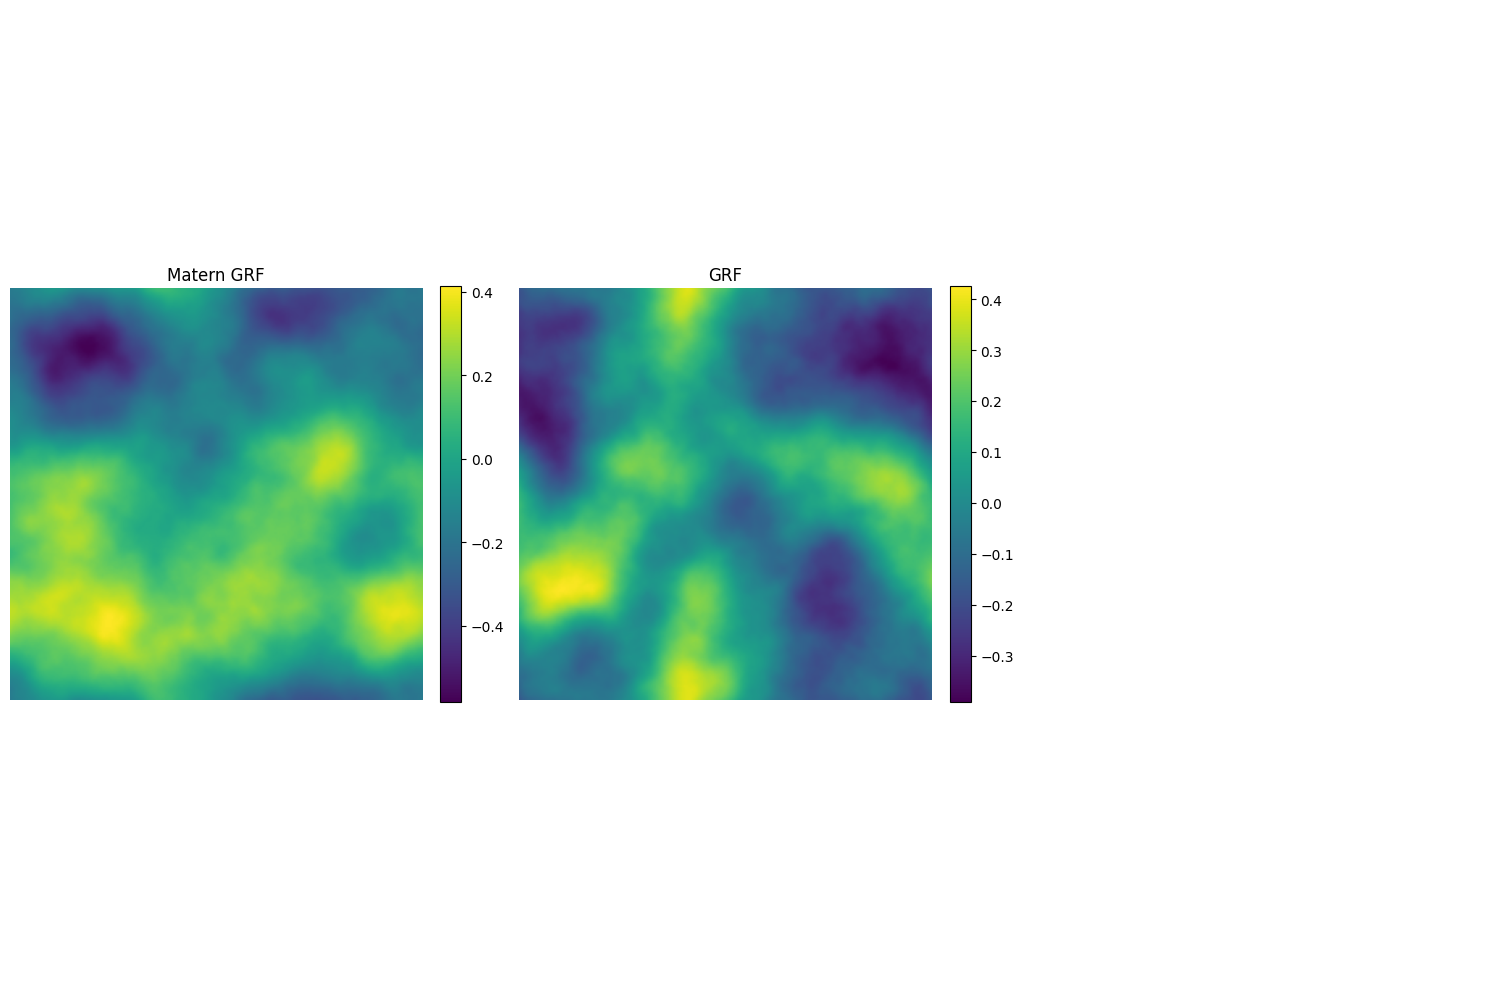

In [46]:

class GaussianRF(object):

    def __init__(self, dim, size, alpha=2, tau=3, sigma=None, boundary="periodic", device=None):

        self.dim = dim
        self.device = device

        if sigma is None:
            sigma = tau**(0.5*(2*alpha - self.dim))

        k_max = size//2

        if dim == 1:
            k = torch.cat((torch.arange(start=0, end=k_max, step=1, device=device), \
                           torch.arange(start=-k_max, end=0, step=1, device=device)), 0)

            self.sqrt_eig = size*math.sqrt(2.0)*sigma*((4*(math.pi**2)*(k**2) + tau**2)**(-alpha/2.0))
            self.sqrt_eig[0] = 0.0

        elif dim == 2:
            wavenumers = torch.cat((torch.arange(start=0, end=k_max, step=1, device=device), \
                                    torch.arange(start=-k_max, end=0, step=1, device=device)), 0).repeat(size,1)

            k_x = wavenumers.transpose(0,1)
            k_y = wavenumers

            self.sqrt_eig = (size**2)*math.sqrt(2.0)*sigma*((4*(math.pi**2)*(k_x**2 + k_y**2) + tau**2)**(-alpha/2.0))
            self.sqrt_eig[0,0] = 0.0

        elif dim == 3:
            wavenumers = torch.cat((torch.arange(start=0, end=k_max, step=1, device=device), \
                                    torch.arange(start=-k_max, end=0, step=1, device=device)), 0).repeat(size,size,1)

            k_x = wavenumers.transpose(1,2)
            k_y = wavenumers
            k_z = wavenumers.transpose(0,2)

            self.sqrt_eig = (size**3)*math.sqrt(2.0)*sigma*((4*(math.pi**2)*(k_x**2 + k_y**2 + k_z**2) + tau**2)**(-alpha/2.0))
            self.sqrt_eig[0,0,0] = 0.0

        self.size = []
        for j in range(self.dim):
            self.size.append(size)

        self.size = tuple(self.size)

    def sample(self, N):

        coeff = torch.randn(N, *self.size, dtype=torch.cfloat, device=self.device)
        coeff = self.sqrt_eig * coeff

        return torch.fft.ifftn(coeff, dim=list(range(-1, -self.dim - 1, -1))).real

GRF = GaussianRF(2, size=256, alpha=2.5, tau=7, device=device)
samples = GRF.sample(N=10)

fields = [
    sample_grf,          # Matern GRF
    samples
]

titles = [
    "Matern GRF",
    "GRF",
]

visualize_fields(fields, titles, ncols=3, figsize=(15,10))

/tmp/ipykernel_2475332/22003709.py:4: RuntimeWarning: divide by zero encountered in log
  plt.imshow(np.log(GRF.sqrt_eig.cpu()), cmap='viridis'); plt.title("GaussianRF sqrt_eig"); plt.colorbar()
/tmp/ipykernel_2475332/22003709.py:4: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  plt.imshow(np.log(GRF.sqrt_eig.cpu()), cmap='viridis'); plt.title("GaussianRF sqrt_eig"); plt.colorbar()
/tmp/ipykernel_2475332/22003709.py:7: RuntimeWarning: divide by zero encountered in log
  plt.imshow(np.log(PGRF.sqrt_spec_density.cpu()), cmap='viridis'); plt.title("PeriodicGRF sqrt_spec_density"); plt.colorbar()
/tmp/ipykernel_2475332/22003709.py:7: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  plt.imshow(np.log(PGRF.sqrt_spec_density.cpu()), cmap='viridis'); plt.title("PeriodicGRF sqrt_spec_density"); plt.colorbar()


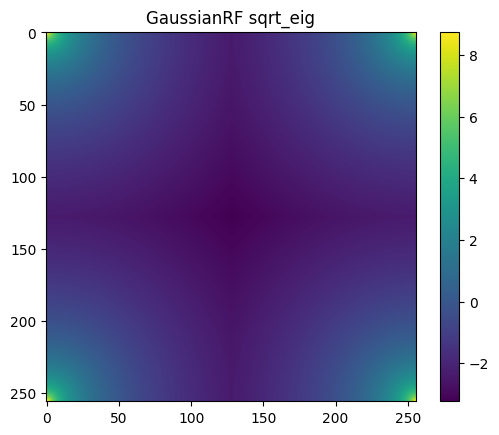

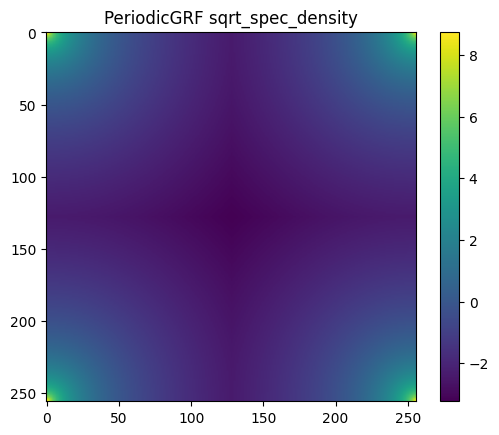

In [47]:
import matplotlib.pyplot as plt
import numpy as np

plt.imshow(np.log(GRF.sqrt_eig.cpu()), cmap='viridis'); plt.title("GaussianRF sqrt_eig"); plt.colorbar()
plt.figure()
PGRF = PeriodicGRF(dim, size, kernel="matern", device=device, alpha=2.5, tau=7.0)
plt.imshow(np.log(PGRF.sqrt_spec_density.cpu()), cmap='viridis'); plt.title("PeriodicGRF sqrt_spec_density"); plt.colorbar()

In [48]:
GRF.sqrt_eig

tensor([[   0.0000, 6325.5063, 2187.2856,  ...,  946.7919, 2187.2856,
         6325.5063],
        [6325.5063, 3988.5276, 1758.3630,  ...,  842.7081, 1758.3630,
         3988.5276],
        [2187.2856, 1758.3630, 1076.5464,  ...,  626.9886, 1076.5464,
         1758.3630],
        ...,
        [ 946.7919,  842.7081,  626.9886,  ...,  430.4300,  626.9886,
          842.7081],
        [2187.2856, 1758.3630, 1076.5464,  ...,  626.9886, 1076.5464,
         1758.3630],
        [6325.5063, 3988.5276, 1758.3630,  ...,  842.7081, 1758.3630,
         3988.5276]])

In [49]:
PGRF.sqrt_spec_density

tensor([[   0.0000,    0.0000,    0.0000,  ...,    0.0000,    0.0000,
            0.0000],
        [6325.5063, 3988.5281, 1758.3630,  ...,  842.7081, 1758.3630,
         3988.5281],
        [2187.2856, 1758.3630, 1076.5466,  ...,  626.9886, 1076.5466,
         1758.3630],
        ...,
        [ 946.7919,  842.7081,  626.9886,  ...,  430.4301,  626.9886,
          842.7081],
        [2187.2856, 1758.3630, 1076.5466,  ...,  626.9886, 1076.5466,
         1758.3630],
        [6325.5063, 3988.5281, 1758.3630,  ...,  842.7081, 1758.3630,
         3988.5281]])

In [36]:
PGRF.sqrt_spec_density**2

tensor([[     0.0000,      0.0000,      0.0000,  ...,      0.0000,
              0.0000,      0.0000],
        [116653.1406,  46380.0469,   9014.1123,  ...,   2070.4287,
           9014.1123,  46380.0469],
        [ 13948.1592,   9014.1123,   3378.8704,  ...,   1146.1071,
           3378.8704,   9014.1123],
        ...,
        [  2613.4548,   2070.4287,   1146.1071,  ...,    540.1459,
           1146.1071,   2070.4287],
        [ 13948.1592,   9014.1123,   3378.8704,  ...,   1146.1071,
           3378.8704,   9014.1123],
        [116653.1406,  46380.0469,   9014.1123,  ...,   2070.4287,
           9014.1123,  46380.0469]])

In [42]:
GRF.sqrt_eig/PGRF.sqrt_spec_density

tensor([[    nan,     inf,     inf,  ...,     inf,     inf,     inf],
        [18.5203, 18.5203, 18.5203,  ..., 18.5203, 18.5203, 18.5203],
        [18.5203, 18.5203, 18.5203,  ..., 18.5203, 18.5203, 18.5203],
        ...,
        [18.5203, 18.5203, 18.5203,  ..., 18.5203, 18.5203, 18.5203],
        [18.5203, 18.5203, 18.5203,  ..., 18.5203, 18.5203, 18.5203],
        [18.5203, 18.5203, 18.5203,  ..., 18.5203, 18.5203, 18.5203]])

In [43]:
18.5203**2

343.00151208999995

In [44]:
7**1.5

18.520259177452136

In [30]:
GRF.sqrt_eig/(PGRF.sqrt_spec_density**2)

tensor([[    nan,     inf,     inf,  ...,     inf,     inf,     inf],
        [18.5203, 18.5203, 18.5203,  ..., 18.5203, 18.5203, 18.5203],
        [18.5203, 18.5203, 18.5203,  ..., 18.5203, 18.5203, 18.5203],
        ...,
        [18.5203, 18.5203, 18.5203,  ..., 18.5203, 18.5203, 18.5203],
        [18.5203, 18.5203, 18.5203,  ..., 18.5203, 18.5203, 18.5203],
        [18.5203, 18.5203, 18.5203,  ..., 18.5203, 18.5203, 18.5203]])

In [54]:
sample_log_grf.mean(axis=(1,2)).shape

torch.Size([10])

In [57]:
sample_log_grf.mean(axis=(1,2), keepdim=True)

tensor([[[-8.3923e-05]],

        [[ 5.6836e-01]],

        [[ 5.7373e-03]],

        [[ 1.3794e-02]],

        [[ 5.5000e+00]],

        [[ 2.8125e-01]],

        [[ 1.5259e-04]],

        [[ 2.3193e-03]],

        [[ 4.6875e-01]],

        [[ 3.0518e-03]]])

In [60]:
sample_log_grf.mean(axis=(1,2), keepdim=True)

tensor([[[ 1.6785e-04]],

        [[-4.5776e-05]],

        [[-8.2812e-01]],

        [[-4.3750e+00]],

        [[ 8.8750e+00]],

        [[ 7.3242e-03]],

        [[ 2.6367e-02]],

        [[ 1.4062e-01]],

        [[-6.5430e-02]],

        [[-1.6689e-06]]])

In [67]:
sample_log_grf = torch.exp(50*sample_grf)
mean_per_sample = sample_log_grf.mean(dim=(1,2), keepdim=True)  # shape (10,1,1)
# sample_log_grf = sample_log_grf - mean_per_sample

In [68]:
sample_log_grf[0]

tensor([[  51.6727,   42.6707,   36.8772,  ...,  219.3268,  122.3433,
           70.9207],
        [  23.8211,   21.7338,   19.0278,  ...,  100.3194,   55.7115,
           31.0538],
        [  10.6633,   10.0265,    9.2775,  ...,   47.3547,   26.4495,
           14.7390],
        ...,
        [ 558.1889,  372.9424,  253.7123,  ..., 1799.3540, 1152.5885,
          809.2195],
        [ 268.8943,  182.2945,  132.4580,  ...,  846.5239,  544.7380,
          385.7571],
        [ 117.5392,   88.2131,   71.7339,  ...,  424.9901,  268.6233,
          174.3052]])

In [63]:
mean_per_sample

tensor([[[6.1109e+03]],

        [[9.5833e+03]],

        [[8.4310e+06]],

        [[1.6044e+08]],

        [[1.3994e+08]],

        [[4.5064e+05]],

        [[2.4795e+06]],

        [[1.4908e+07]],

        [[7.9296e+05]],

        [[3.9641e+02]]])

In [65]:
sample_log_grf.mean(dim=(1,2), keepdim=True)

tensor([[[ 1.6785e-04]],

        [[-4.5776e-05]],

        [[-8.2812e-01]],

        [[-4.3750e+00]],

        [[ 8.8750e+00]],

        [[ 7.3242e-03]],

        [[ 2.6367e-02]],

        [[ 1.4062e-01]],

        [[-6.5430e-02]],

        [[-1.6689e-06]]])

In [66]:
sample_log_grf[0]

tensor([[-6059.2227, -6068.2246, -6074.0186,  ..., -5891.5688, -5988.5522,
         -6039.9746],
        [-6087.0742, -6089.1616, -6091.8677,  ..., -6010.5762, -6055.1841,
         -6079.8418],
        [-6100.2324, -6100.8691, -6101.6182,  ..., -6063.5410, -6084.4458,
         -6096.1567],
        ...,
        [-5552.7065, -5737.9531, -5857.1831,  ..., -4311.5415, -4958.3071,
         -5301.6758],
        [-5842.0010, -5928.6011, -5978.4375,  ..., -5264.3716, -5566.1577,
         -5725.1387],
        [-5993.3564, -6022.6826, -6039.1616,  ..., -5685.9053, -5842.2725,
         -5936.5903]])